## DAMO510, Predictive Analytics, Take-Home Assignment 1:
### Predicting Airbnb Prices in Vancouver

Background
Airbnb has transformed the short-term rental market in cities worldwide, including Vancouver. With thousands of listings across diverse neighbourhoods, prices vary widely depending on property type, amenities, location, and host characteristics. However, the raw data collected from Airbnb is often messy: missing values, inconsistent formats, extreme outliers, and complex categorical variables.
In this assignment, you will act as a data analyst tasked with cleaning, transforming, and modeling Airbnb data to predict nightly listing prices. This exercise mirrors real-world challenges faced by analysts in housing, tourism, and urban planning, where data quality issues must be addressed before meaningful insights can be drawn.
You will use the official Vancouver Airbnb dataset, available from here.

A full data dictionary has been provided separately for reference.
## Instructions
### 1.	Data Cleaning
o	Identify and handle missing values across multiple variables.
o	Detect and treat outliers in price.
o	Standardize categorical labels.
o	Document your cleaning decisions clearly, explaining why certain records were removed, imputed, or transformed.
### 2.	Data Transformation
o	Encode categorical variables using appropriate methods.
o	Reminder: Avoid data leakage — fit encoders only on the training set, then apply them to the test set.
o	Identify skewed numerical variables.
o	Apply appropriate transformations to stabilize variance and improve normality. Your focus should be on Box-Cox and Yeo-Johnson transformations. However, in the case of poor performance of the above methods, use alternative methods. 
o	Parse complex fields like amenities into usable binary features.
o	Create at least two interaction terms.
### 3.	Regression Modeling
o	Fit and evaluate a Linear Regression model to predict nightly prices.
o	Compare performance using absolute and relative MSE, RMSE, and MAE.
o	Provide detailed interpretation of coefficients and discuss trade-offs between interpretability and predictive accuracy.
### 4.	Evaluation & Reflection
o	Summarize cleaning and transformation steps in detail.
o	Justify modeling choices and feature engineering decisions.
o	Reflect on how messy data and leakage risks affected your results.
o	Discuss limitations of your model and suggest possible improvements (e.g., nonlinear models, additional features).



# 1 Import lib and Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("listings.csv")

In [5]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13188,https://www.airbnb.com/rooms/13188,20251017043359,2025-10-17,city scrape,Garden level studio in ideal loc.,Garden level studio suite with garden patio - ...,The uber hip Main street area is a short walk ...,https://a0.muscache.com/pictures/8408188/e1af6...,51466,...,4.93,4.91,4.81,Municipal registration number: 25-156058<br />...,f,1,1,0,0,2.00
1,18270,https://www.airbnb.com/rooms/18270,20251017043359,2025-10-17,city scrape,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a...,"Lots of restaurants, coffee shops.<br />Easy a...",https://a0.muscache.com/pictures/108520241/aec...,70437,...,4.73,4.69,4.49,NaN,f,1,0,1,0,0.66
2,18589,https://www.airbnb.com/rooms/18589,20251017043359,2025-10-17,city scrape,Commercial Drive B&B,"As hosts, we are welcoming you into our home, ...",Lots of restaurants and boutiques just outside...,https://a0.muscache.com/pictures/dd3ca406-cb74...,71508,...,5.00,4.93,4.95,Municipal registration number: 25-155972<br />...,f,1,0,1,0,3.61
3,18795,https://www.airbnb.com/rooms/18795,20251017043359,2025-10-17,city scrape,*Best choice in downtown-5 Stars * -2,NaN,NaN,https://a0.muscache.com/pictures/96249/03d3af8...,70137,...,4.66,4.88,4.50,Municipal registration number: 18-573700,f,4,0,4,0,0.74
4,20085,https://www.airbnb.com/rooms/20085,20251017043359,2025-10-17,city scrape,Cozy Oasis Uptown Garden Suite,"Your private, fully furnished suite is central...",This beautiful garden suite on a quiet tree-li...,https://a0.muscache.com/pictures/miso/Hosting-...,75986,...,4.88,4.53,4.78,NaN,f,1,1,0,0,0.42


In [6]:
df.shape

(4705, 79)

In [7]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4705 entries, 0 to 4704
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4705 non-null   int64  
 1   listing_url                                   4705 non-null   object 
 2   scrape_id                                     4705 non-null   int64  
 3   last_scraped                                  4705 non-null   object 
 4   source                                        4705 non-null   object 
 5   name                                          4705 non-null   object 
 6   description                                   4670 non-null   object 
 7   neighborhood_overview                         2275 non-null   object 
 8   picture_url                                   4705 non-null   object 
 9   host_id                                       4705 non-null   i

In [9]:
df.isna().mean().sort_values(ascending=False).head(25)


calendar_updated                1.000000
neighbourhood_group_cleansed    1.000000
neighbourhood                   0.516472
neighborhood_overview           0.516472
host_about                      0.500531
host_location                   0.232731
license                         0.225505
last_review                     0.136238
review_scores_rating            0.136238
review_scores_accuracy          0.136238
review_scores_cleanliness       0.136238
review_scores_checkin           0.136238
reviews_per_month               0.136238
review_scores_communication     0.136238
review_scores_value             0.136238
review_scores_location          0.136238
first_review                    0.136238
host_response_time              0.115622
host_response_rate              0.115622
host_acceptance_rate            0.058874
host_neighbourhood              0.036557
host_is_superhost               0.035282
description                     0.007439
has_availability                0.004463
bedrooms        

# 2 Data Cleaning

We inspected dataset dimensions, variable types, and missingness rates to guide the cleaning plan.
Variables with 0% non-null values were removed immediately.
High-missing variables were evaluated based on expected predictive value and feasibility of imputation.


## Feature Removal Rules (Pre-Modeling)

### We removed the following groups of variables before model training:

1 - Completely Empty Columns
Variables with 0 non-null values were removed, as they provide no usable information.

2 - Identifiers & URLs
Listing IDs, host IDs, and URLs uniquely identify records but do not explain price variation and may introduce noise into the model.

3 - Scraping Metadata
Fields related to data extraction (e.g., scrape timestamps, source) were excluded since they are unrelated to housing characteristics or market dynamics.

4 - Unstructured Text Features
Free-text variables (e.g., name, description, host_about) were excluded because natural language processing was outside the scope of this linear regression pipeline.

5 - High-Missing / Raw Duplicate Versions
Raw or partially duplicated variables (e.g., neighbourhood vs neighbourhood_cleansed, bathrooms_text vs bathrooms) were removed to keep only the cleaned or structured versions.

6 - Redundant Aggregations & Derived Fields
Multiple derived night constraints and availability windows were reduced to their core variables (e.g., keeping availability_365, minimum_nights, maximum_nights) to limit multicollinearity and simplify interpretation.

7 - Review Sub-scores
Individual review subcomponents (e.g., cleanliness, communication, location) were removed while retaining the overall rating to reduce dimensionality and avoid redundancy.

8 - Host Listing Redundancies
Multiple host listing count variations were reduced to a single consolidated measure to prevent overlapping information.

9 - Data Leakage / Future Information
Variables that encode future performance (e.g., estimated revenue, occupancy, recent review counts, first/last review dates) were excluded to prevent leakage and ensure realistic model evaluation.

In [10]:
cols_drop = []

# =====================================================
# 1) Completely Empty Columns
# =====================================================
cols_drop += [
    "neighbourhood_group_cleansed",
    "calendar_updated"
]

# =====================================================
# 2) Identifiers & URLs (pure IDs, no predictive value)
# =====================================================
cols_drop += [
    "id", "listing_url", "scrape_id", "picture_url",
    "host_id", "host_url", "host_thumbnail_url", "host_picture_url"
]

# =====================================================
# 3) Scraping Metadata
# =====================================================
cols_drop += [
    "last_scraped",
    "calendar_last_scraped",
    "source"
]

# =====================================================
# 4) Unstructured Text Features
# =====================================================
cols_drop += [
    "name",
    "description",
    "neighborhood_overview",
    "host_about"
]

# =====================================================
# 5) High Missing / Redundant Raw Versions
# =====================================================
cols_drop += [
    "neighbourhood",       
    "bathrooms_text"        
]

# =====================================================
# 6) Host Listing Redundancies
# (keeping only calculated_host_listings_count)
# =====================================================
cols_drop += [
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms"
]

# =====================================================
# 7) Availability Redundancies
# (keeping only availability_365)
# =====================================================
cols_drop += [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_eoy"
]

# =====================================================
# 8) Review Sub-scores (keeping review_scores_rating only)
# =====================================================
cols_drop += [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

# =====================================================
# 9) Nights Redundant Aggregations
# (keeping minimum_nights and maximum_nights only)
# =====================================================
cols_drop += [
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "minimum_nights_avg_ntm", "maximum_nights_avg_ntm"
]

# =====================================================
# 10) Leakage / Future Information
# =====================================================
cols_drop += [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "first_review",
    "last_review"
]

# =====================================================
# 11) Non-Predictive Host Info
# =====================================================
cols_drop += [
    "host_location",
    "host_name",
    "host_neighbourhood"
]

# Safety filter
cols_drop = [c for c in cols_drop if c in df.columns]

df1 = df.drop(columns=cols_drop)

df1.shape


(4705, 29)

# Cleaning the Price Variable
The price variable is the target for our regression model, so it is crucial to clean it properly. We will remove outliers and apply transformations to stabilize variance and improve normality.

In [11]:
df1["price_cleaned"] = df1["price"].apply(lambda x: float(str(x).replace("$", "").replace(",", "")))

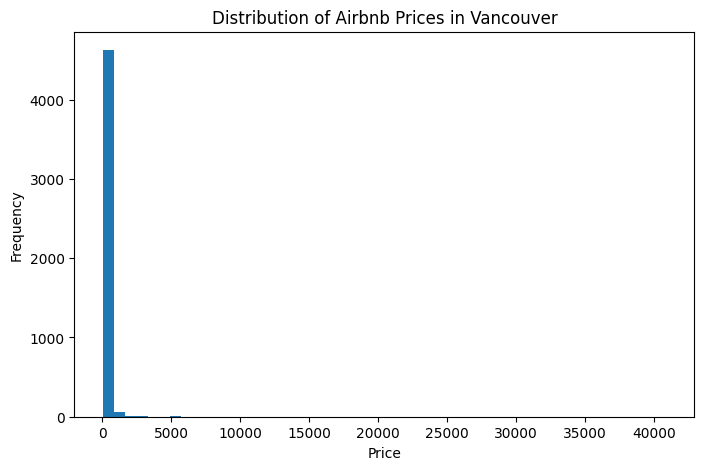

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df1["price_cleaned"].dropna(), bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Airbnb Prices in Vancouver")
plt.show()


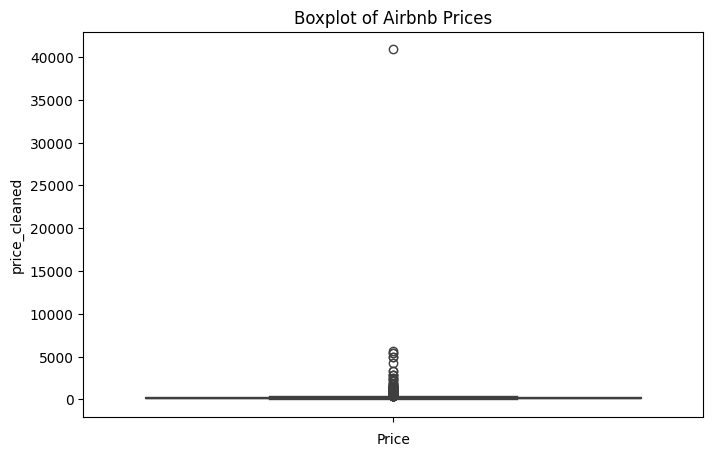

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(y=df1["price_cleaned"])
plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price")
plt.show()


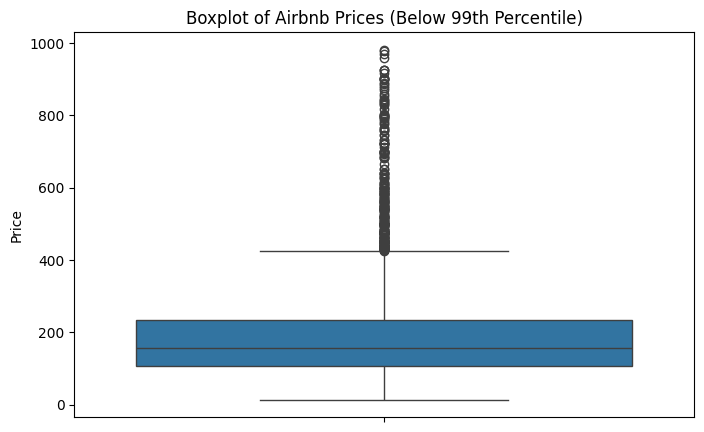

In [14]:
p99 = df1["price_cleaned"].quantile(0.99)

plt.figure(figsize=(8,5))
sns.boxplot(y=df1[df1["price_cleaned"] <= p99]["price_cleaned"])
plt.title("Boxplot of Airbnb Prices (Below 99th Percentile)")
plt.ylabel("Price")
plt.show()


In [15]:
df1["price_cleaned"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])


count     4702.000000
mean       219.756061
std        650.225951
min         14.000000
50%        158.000000
75%        239.000000
90%        365.000000
95%        477.950000
99%        988.930000
max      40896.000000
Name: price_cleaned, dtype: float64

## Outliers in `price`
I use percentiles to detect extreme values. Outliers distort linear regression and can inflate error metrics.

The raw price distribution is highly right-skewed, with extreme high-value outliers reaching above $40,000. 
These extreme values compress the majority of observations into a narrow range and may negatively impact linear regression performance.

To better visualize the central mass of the distribution, we examined prices below the 99th percentile. 
Additionally, we explored a log transformation to stabilize variance and reduce skewness.


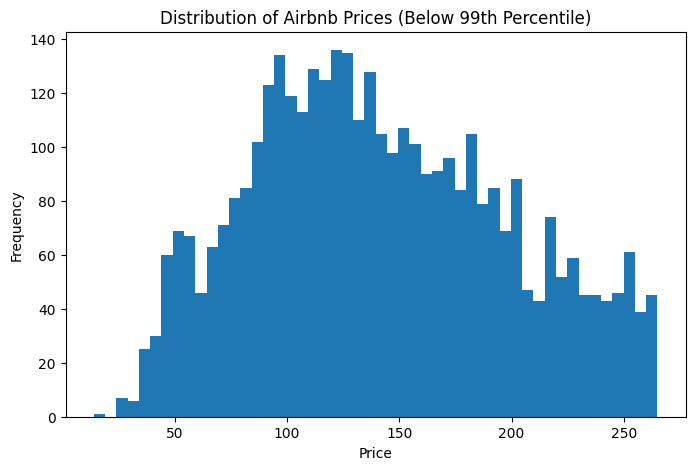

In [16]:
p99 = df1["price_cleaned"].quantile(0.80)

plt.figure(figsize=(8,5))
plt.hist(df1[df1["price_cleaned"] <= p99]["price_cleaned"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Airbnb Prices (Below 99th Percentile)")
plt.show()


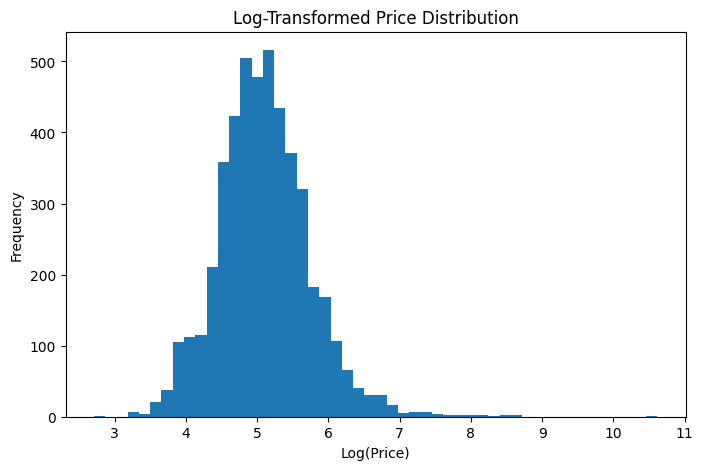

In [17]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df1["price_cleaned"]), bins=50)
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Price Distribution")
plt.show()


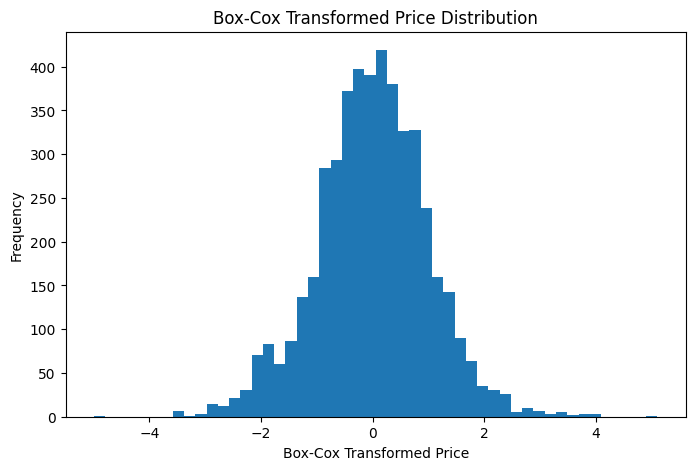

In [18]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="box-cox")
plt.figure(figsize=(8,5))
plt.hist(pt.fit_transform(df1[["price_cleaned"]].dropna()), bins=50)
plt.xlabel("Box-Cox Transformed Price")
plt.ylabel("Frequency")
plt.title("Box-Cox Transformed Price Distribution")
plt.show()

In [19]:
df1["log_price"] = np.log1p(df1["price_cleaned"])
df1["log_price"].dropna(inplace=True)
df1["box_cox_price"] = pt.fit_transform(df1[["price_cleaned"]])

In [20]:
print(df1["log_price"].skew())
print(df1["box_cox_price"].skew())

0.6981054448258898
-0.0430520436755483


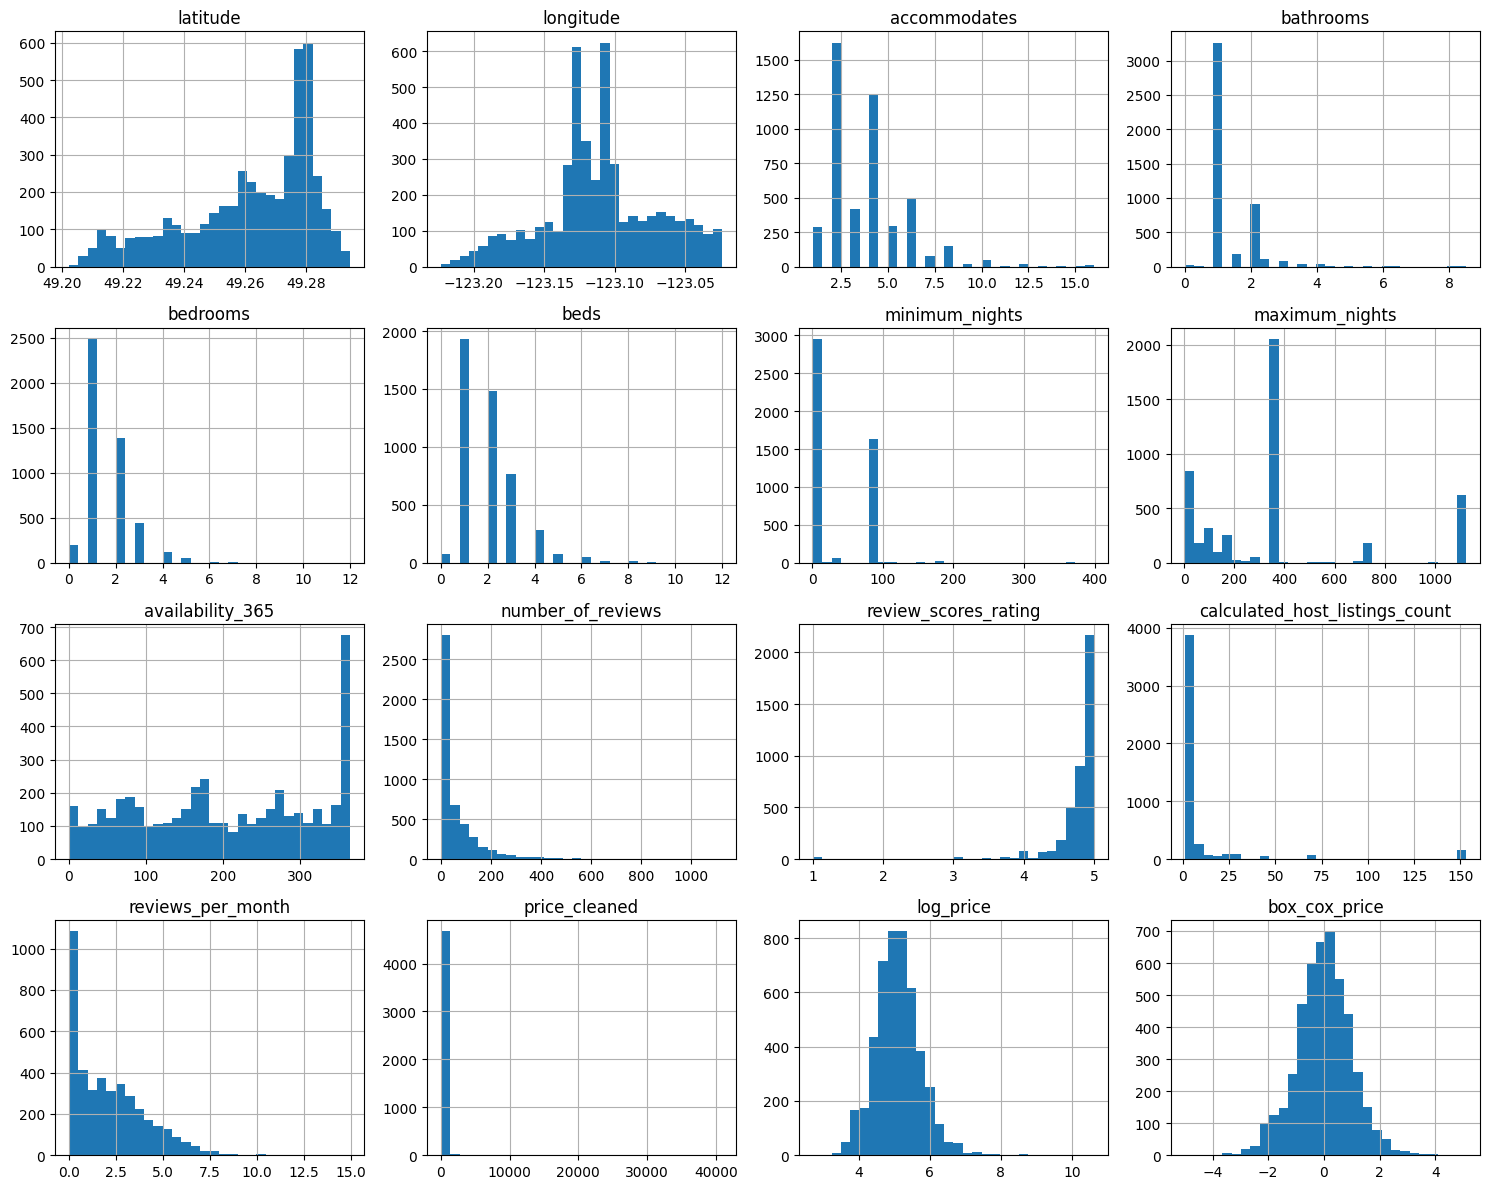

In [21]:
df1.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

In [22]:
from scipy.stats import skew


skew_values = df1.dropna().select_dtypes(include="number").apply(lambda x: skew(x))
skew_values.sort_values(ascending=False)


price_cleaned                     46.370517
calculated_host_listings_count     6.884942
number_of_reviews                  3.010608
minimum_nights                     2.693632
bathrooms                          2.570109
bedrooms                           1.501377
beds                               1.491641
accommodates                       1.450035
maximum_nights                     1.237314
reviews_per_month                  1.075962
log_price                          0.840647
availability_365                   0.181703
box_cox_price                      0.031719
longitude                         -0.167163
latitude                          -0.667647
review_scores_rating              -6.149438
dtype: float64

In [23]:
cols_to_transform = [
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights",
    "maximum_nights",
    "calculated_host_listings_count"
]
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df1[cols_to_transform] = pt.fit_transform(df1[cols_to_transform])


## Yeo-Johnson on skewed variables
I apply `PowerTransformer(method="yeo-johnson")` to highly skewed variables to make them more normly distributed and improve model fit.

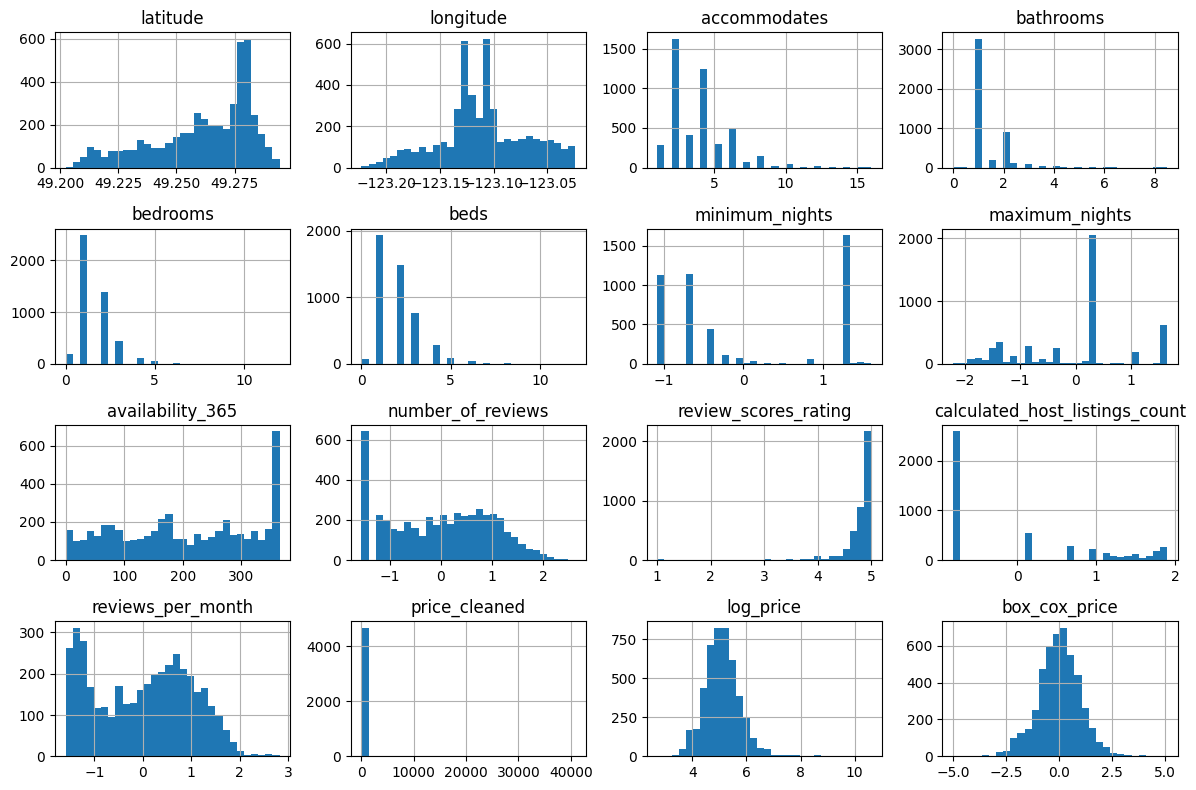

In [24]:
df1.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()


# Cleaning the feature variables
We will apply similar cleaning and transformation steps to the feature variables.
This includes handling missing values, encoding categorical variables, and applying transformations to skewed numerical features.

### Step 1: Numerical Features

In [25]:
numeric_df = df1.select_dtypes(include=[np.number]).copy()
numeric_df.shape


(4705, 16)

In [26]:
corr_matrix = numeric_df.corr()
corr_matrix.head()


,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,calculated_host_listings_count,reviews_per_month,price_cleaned,log_price,box_cox_price
latitude,1.000000,-0.065034,-0.063369,-0.052079,-0.117965,-0.067346,0.196473,0.070019,0.023007,-0.016860,0.025173,-0.004660,-0.078678,0.052879,0.199455,0.207439
longitude,-0.065034,1.000000,0.038664,-0.037190,0.048090,0.022421,-0.085101,-0.072705,0.014209,0.112587,0.063147,-0.116524,0.107488,-0.034509,-0.100202,-0.098272
accommodates,-0.063369,0.038664,1.000000,0.657898,0.824304,0.847940,-0.226663,0.012044,-0.066890,0.111396,0.015436,-0.145207,0.181848,0.155216,0.596080,0.595227
bathrooms,-0.052079,-0.037190,0.657898,1.000000,0.716688,0.606457,-0.026168,0.021040,-0.005902,-0.066202,0.013940,-0.019678,-0.005243,0.165140,0.517193,0.490247
bedrooms,-0.117965,0.048090,0.824304,0.716688,1.000000,0.783298,-0.127439,0.010266,-0.029780,0.008516,-0.001681,-0.087404,0.081599,0.159643,0.531836,0.516884


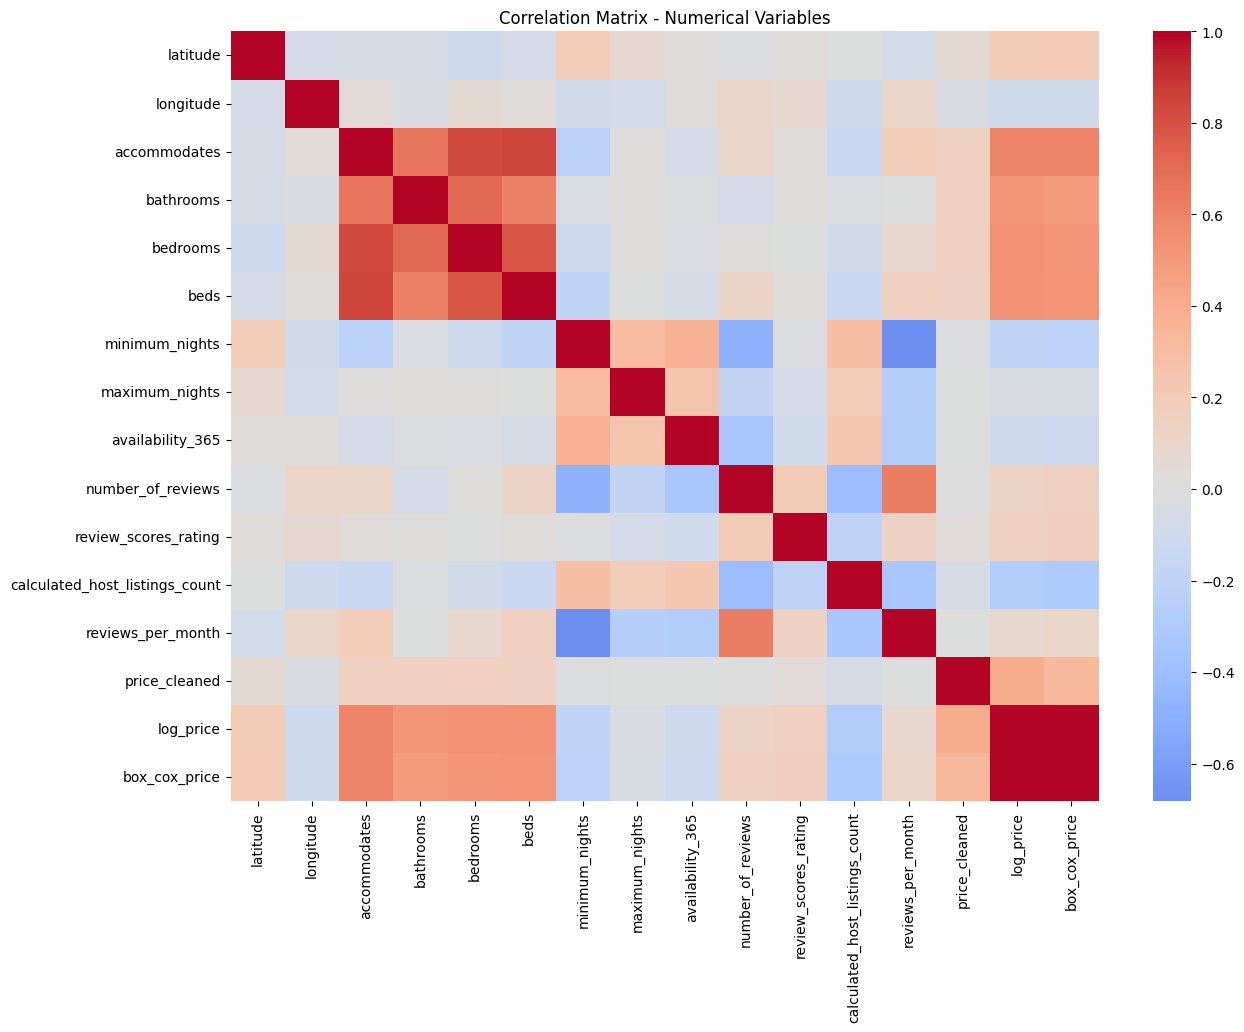

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Numerical Variables")
plt.show()


In [28]:
# Obtener solo la parte superior del triángulo
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Filtrar correlaciones altas
high_corr = [
    (column, row, upper.loc[row, column])
    for column in upper.columns
    for row in upper.index
    if abs(upper.loc[row, column]) > 0.75
]

high_corr


[('bedrooms', 'accommodates', np.float64(0.8243035671582337)),
 ('beds', 'accommodates', np.float64(0.8479401858178436)),
 ('beds', 'bedrooms', np.float64(0.7832983427450636)),
 ('box_cox_price', 'log_price', np.float64(0.9909096097527248))]

## Multicollinearity
I check high correlations among numeric variables and remove redundancies to avoid unstable coefficients.

The correlation matrix revealed strong clusters among review score sub-metrics, availability variables, and host listing counts. 
To reduce multicollinearity, redundant variables were removed while retaining the most interpretable and comprehensive representative within each group.


### Categorical Features
Cleaning

In [29]:
categoric_df = df1.select_dtypes(include=["object"]).copy()

In [30]:
categoric_df.shape

(4705, 16)

In [31]:
categoric_df.head()

,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,amenities,price,has_availability,license,instant_bookable
0,2009-11-04,within a few hours,100%,100%,t,"['email', 'phone']",t,t,Riley Park,Entire guest suite,Entire home/apt,"[""Bathtub"", ""Dishes and silverware"", ""Shampoo""...",$138.00,t,Municipal registration number: 25-156058<br />...,f
1,2010-01-14,NaN,NaN,NaN,f,"['email', 'phone']",t,t,Mount Pleasant,Private room in condo,Private room,"[""Dishes and silverware"", ""Shampoo"", ""Refriger...",$47.00,t,NaN,f
2,2010-01-18,within an hour,100%,100%,t,"['email', 'phone']",t,t,Grandview-Woodland,Private room in home,Private room,"[""Bathtub"", ""Dishes and silverware"", ""Dedicate...",$140.00,t,Municipal registration number: 25-155972<br />...,f
3,2010-01-13,a few days or more,0%,100%,f,"['email', 'phone']",t,t,West End,Private room in home,Private room,"[""Heating"", ""Dishes and silverware"", ""Dedicate...",$75.00,t,Municipal registration number: 18-573700,f
4,2010-01-31,within an hour,100%,100%,f,"['email', 'phone']",t,t,Kensington-Cedar Cottage,Entire guest suite,Entire home/apt,"[""Bathtub"", ""Dishes and silverware"", ""Dedicate...",$136.00,t,NaN,f


In [32]:
categoric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4705 entries, 0 to 4704
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   host_since              4705 non-null   object
 1   host_response_time      4161 non-null   object
 2   host_response_rate      4161 non-null   object
 3   host_acceptance_rate    4428 non-null   object
 4   host_is_superhost       4539 non-null   object
 5   host_verifications      4705 non-null   object
 6   host_has_profile_pic    4705 non-null   object
 7   host_identity_verified  4705 non-null   object
 8   neighbourhood_cleansed  4705 non-null   object
 9   property_type           4705 non-null   object
 10  room_type               4705 non-null   object
 11  amenities               4705 non-null   object
 12  price                   4702 non-null   object
 13  has_availability        4684 non-null   object
 14  license                 3644 non-null   object
 15  inst

In [33]:

categoric_df = categoric_df.drop(columns="price")

In [34]:
categoric_df["host_since"] = pd.to_datetime(categoric_df["host_since"], errors="coerce")
categoric_df["host_years"] = (pd.Timestamp.today() - categoric_df["host_since"]).dt.days / 365
categoric_df = categoric_df.drop(columns=["host_since"])
categoric_df["host_years"].describe()

count    4705.000000
mean        7.252040
std         4.116053
min         0.367123
25%         3.504110
50%         7.287671
75%        10.416438
max        17.134247
Name: host_years, dtype: float64

In [35]:
percent_cols = ["host_response_rate", "host_acceptance_rate"]

for col in percent_cols:
    categoric_df[col] = (
        categoric_df[col]
        .str.replace("%", "", regex=False)
        .astype(float) / 100
    )
categoric_df[percent_cols].describe()

,host_response_rate,host_acceptance_rate
count,4161.000000,4428.000000
mean,0.970125,0.889207
std,0.121696,0.212932
min,0.000000,0.000000
25%,1.000000,0.910000
50%,1.000000,0.980000
75%,1.000000,1.000000
max,1.000000,1.000000


In [36]:
bool_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable",
    "has_availability"
]

for col in bool_cols:
    categoric_df[col] = categoric_df[col].map({"t": 1, "f": 0})


In [37]:
categoric_df["host_verifications"]

0                     ['email', 'phone']
1                     ['email', 'phone']
2                     ['email', 'phone']
3                     ['email', 'phone']
4                     ['email', 'phone']
                      ...               
4700    ['email', 'phone', 'work_email']
4701    ['email', 'phone', 'work_email']
4702                           ['phone']
4703                  ['email', 'phone']
4704                  ['email', 'phone']
Name: host_verifications, Length: 4705, dtype: object

In [38]:
categoric_df["host_verifications"][0]

"['email', 'phone']"

In [39]:
categoric_df["host_verifications_count"] = categoric_df["host_verifications"].apply(lambda x: len(str(x).split(",")) if pd.notna(x) else 0)
categoric_df.drop(columns=["host_verifications"], inplace=True)

In [40]:
categoric_df["host_verifications_count"] 

0       2
1       2
2       2
3       2
4       2
       ..
4700    3
4701    3
4702    1
4703    2
4704    2
Name: host_verifications_count, Length: 4705, dtype: int64

In [41]:
categoric_df["host_response_time"].value_counts()

host_response_time
within an hour        3277
within a few hours     582
within a day           244
a few days or more      58
Name: count, dtype: int64

In [42]:
RESPONSES = {
    "within an hour": 1,
    "within a few hours": 2,
    "within a day": 3,
    "a few days or more": 4,
    np.nan: 5
}
categoric_df["host_response_time_encoded"] = categoric_df["host_response_time"].map(RESPONSES)
categoric_df.drop(columns=["host_response_time"], inplace=True)

In [43]:
categoric_df["has_license"] = categoric_df["license"].notna().astype(int)
categoric_df.drop(columns=["license"], inplace=True)

In [44]:
categoric_df["room_type"].value_counts()

room_type
Entire home/apt    3749
Private room        942
Shared room          14
Name: count, dtype: int64

In [45]:
categoric_df["property_type"].value_counts()


property_type
Entire rental unit                   1262
Entire home                           983
Private room in home                  731
Entire condo                          673
Entire guest suite                    522
Entire guesthouse                      89
Private room in rental unit            86
Entire loft                            73
Entire serviced apartment              55
Entire townhouse                       54
Private room in condo                  45
Private room in villa                  13
Room in boutique hotel                 12
Private room in guest suite            11
Private room in townhouse              11
Private room in bed and breakfast       9
Entire villa                            9
Private room in guesthouse              8
Room in hotel                           7
Tiny home                               7
Shared room in home                     6
Camper/RV                               5
Shared room in hotel                    4
Entire bungalow     

In [46]:
top_types = categoric_df["property_type"].value_counts().nlargest(5).index

categoric_df["property_type"] = categoric_df["property_type"].apply(
    lambda x: x if x in top_types else "Other"
)

In [47]:
categoric_df["neighbourhood_cleansed"].nunique()


23

In [48]:
import json
categoric_df["amenities"] = categoric_df["amenities"].apply(lambda x: json.loads(x))
categoric_df["amenities"][0]

['Bathtub',
 'Dishes and silverware',
 'Shampoo',
 'Refrigerator',
 'Toaster',
 'Luggage dropoff allowed',
 'Essentials',
 'Iron',
 'Room-darkening shades',
 'Folding or convertible high chair',
 'Shower gel',
 'EV charger',
 'Kitchenette',
 'TV with standard cable',
 'Mini fridge',
 'Fire extinguisher',
 'Hair dryer',
 'Conditioner',
 'Laundromat nearby',
 'Carbon monoxide alarm',
 'Body soap',
 'Wine glasses',
 'Lockbox',
 'Private entrance',
 'Microwave',
 'Coffee maker: french press, Nespresso',
 'Freezer',
 'Crib',
 'Heating',
 'Sound system',
 'Private backyard – Not fully fenced',
 'Indoor fireplace',
 'Portable fans',
 'BBQ grill',
 'Wifi',
 'Extra pillows and blankets',
 'Pack ’n play/Travel crib',
 'Smoke alarm',
 'Long term stays allowed',
 'Clothing storage: closet',
 'Drying rack for clothing',
 'Hangers',
 'Free street parking',
 'Coffee',
 'Rice maker',
 'Bed linens',
 'Outdoor dining area',
 'Blender',
 'Washer',
 'Self check-in',
 'Hot water',
 'Outdoor furniture',
 'E

In [49]:
categoric_df["has_wifi"] = categoric_df["amenities"].apply(lambda x: int("Wifi" in x))
categoric_df["has_kitchen"] = categoric_df["amenities"].apply(lambda x: int("Kitchen" in x))
categoric_df["has_heating"] = categoric_df["amenities"].apply(lambda x: int("Heating" in x))
categoric_df["has_ac"] = categoric_df["amenities"].apply(lambda x: int("Air conditioning" in x))
categoric_df["has_parking"] = categoric_df["amenities"].apply(lambda x: int("Parking" in x))

categoric_df.drop(columns=["amenities"], inplace=True)

## Amenities as binary features
I convert `amenities` into 0/1 indicators (wifi, kitchen, heating, etc.) so they are usable by the linear model.

In [50]:
final_df = pd.concat([numeric_df, categoric_df], axis=1)
final_df.shape

(4705, 35)

In [51]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4705 entries, 0 to 4704
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        4705 non-null   float64
 1   longitude                       4705 non-null   float64
 2   accommodates                    4705 non-null   int64  
 3   bathrooms                       4702 non-null   float64
 4   bedrooms                        4698 non-null   float64
 5   beds                            4703 non-null   float64
 6   minimum_nights                  4705 non-null   float64
 7   maximum_nights                  4705 non-null   float64
 8   availability_365                4705 non-null   int64  
 9   number_of_reviews               4705 non-null   float64
 10  review_scores_rating            4064 non-null   float64
 11  calculated_host_listings_count  4705 non-null   float64
 12  reviews_per_month               40

## We will perform the train-test split before applying any transformations in order to prevent data leakage.

In [52]:
from sklearn.model_selection import train_test_split

final_df = final_df.dropna(subset=["log_price", "box_cox_price"])
X = final_df.drop(columns=["log_price", "box_cox_price", "price_cleaned"])
y = final_df["price_cleaned"]  # O "box_cox_price" dependiendo de la transformación que quieras usar

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## Train/Test split (no leakage)
I split train/test before any imputation or encoding so the model never sees test information during fitting.

In [53]:
y_train.isna().sum(), y_test.isna().sum()


(np.int64(0), np.int64(0))

In [54]:
X_train.isna().mean().sort_values(ascending=False)


review_scores_rating              0.132412
reviews_per_month                 0.132412
host_response_rate                0.115661
host_acceptance_rate              0.057166
host_is_superhost                 0.034034
has_availability                  0.004254
bedrooms                          0.000798
bathrooms                         0.000798
beds                              0.000266
has_heating                       0.000000
has_kitchen                       0.000000
has_wifi                          0.000000
has_license                       0.000000
room_type                         0.000000
host_response_time_encoded        0.000000
has_ac                            0.000000
host_verifications_count          0.000000
host_years                        0.000000
instant_bookable                  0.000000
latitude                          0.000000
host_has_profile_pic              0.000000
property_type                     0.000000
neighbourhood_cleansed            0.000000
host_identi

In [55]:

y_train_bc = pt.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_bc  = pt.transform(y_test.values.reshape(-1, 1)).ravel()

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

Missing review scores were not treated as random noise. 
Listings without reviews were assumed to represent new properties; therefore, missing review variables were replaced with zero and a new binary feature `has_reviews` was created to capture this distinction.

Continuous numerical variables were imputed using the training-set median to ensure robustness against skewness and outliers.

Binary variables were imputed with zero when missing, assuming absence of the feature.


In [56]:
numerical_cols = X_train.select_dtypes(include=[np.number]).columns
corr_matrix = X_train[numerical_cols].corr().abs()


upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.80

to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
print("Features to drop due to high correlation:")
print(to_drop)

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

Features to drop due to high correlation:
['bedrooms', 'beds']


In [57]:
X_train

,latitude,longitude,accommodates,bathrooms,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,calculated_host_listings_count,...,instant_bookable,host_years,host_verifications_count,host_response_time_encoded,has_license,has_wifi,has_kitchen,has_heating,has_ac,has_parking
1838,49.280350,-123.109050,3,1.0,-0.671302,1.656818,161,1.604369,4.83,1.093653,...,0,3.298630,2,1,1,0,1,0,0,0
1420,49.267460,-123.172800,2,1.0,-0.671302,-2.084061,2,0.579199,4.96,-0.815532,...,1,3.986301,1,1,1,1,1,0,0,0
4620,49.287640,-123.125030,5,2.5,-0.222531,1.656818,108,-1.552103,NaN,0.160397,...,1,8.194521,2,1,1,1,1,1,0,0
3622,49.256036,-123.139231,2,1.0,-0.409073,0.309095,89,-0.584568,4.67,0.633807,...,0,1.104110,1,1,1,1,1,0,0,0
3079,49.274882,-123.114633,3,NaN,1.265298,0.309095,364,-1.552103,NaN,1.093653,...,0,3.504110,2,5,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4429,49.264900,-123.075690,5,1.5,1.265298,0.309095,364,-1.552103,NaN,-0.815532,...,0,11.835616,3,2,0,1,1,0,0,0
466,49.277540,-123.112570,2,1.0,1.265298,1.083023,350,-0.876074,4.67,-0.815532,...,0,9.389041,2,1,0,1,1,1,0,0
3095,49.278452,-123.115010,3,1.0,1.265298,1.083023,365,-1.222067,5.00,1.447629,...,0,3.980822,2,2,0,1,1,0,0,0
3775,49.216741,-123.074220,4,2.0,-1.087009,0.309095,99,-0.340878,4.40,1.672911,...,1,6.049315,2,1,1,1,1,1,0,0


## Missing value imputation
I impute continuous variables with the train median and binary fields with 0. For reviews, I add `has_reviews` and fill missing review scores with 0 to flag new listings.

In [58]:
# 1️⃣ Create has_reviews
X_train["has_reviews"] = X_train["review_scores_rating"].notna().astype(int)
X_test["has_reviews"] = X_test["review_scores_rating"].notna().astype(int)

# 2️⃣ Reviews → fill with 0
for col in ["review_scores_rating", "reviews_per_month"]:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

# 3️⃣ Median imputation
median_cols = [
    "host_response_rate",
    "host_acceptance_rate",
]

for col in median_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# 4️⃣ Binary fill with 0
binary_cols = ["host_is_superhost", "has_availability"]

for col in binary_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)


In [59]:
X_train.isna().mean().sort_values(ascending=False)


bathrooms                         0.000798
latitude                          0.000000
neighbourhood_cleansed            0.000000
has_parking                       0.000000
has_ac                            0.000000
has_heating                       0.000000
has_kitchen                       0.000000
has_wifi                          0.000000
has_license                       0.000000
host_response_time_encoded        0.000000
host_verifications_count          0.000000
host_years                        0.000000
instant_bookable                  0.000000
has_availability                  0.000000
room_type                         0.000000
property_type                     0.000000
host_identity_verified            0.000000
longitude                         0.000000
host_has_profile_pic              0.000000
host_is_superhost                 0.000000
host_acceptance_rate              0.000000
host_response_rate                0.000000
reviews_per_month                 0.000000
calculated_

In [60]:
print(X_train["neighbourhood_cleansed"].nunique())
print(X_train["property_type"].nunique())
print(X_train["room_type"].nunique())

23
6
3


## Encoding categorical variables
I use One-Hot Encoding fitted on the training set only, then apply it to the test set to prevent leakage.

In [61]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["neighbourhood_cleansed", "property_type", "room_type"]

ohe = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# Fit SOLO en train
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)

# Convertir a DataFrame
X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_cols,
    index=X_test.index
)

# 🔥 Mantener numéricas
X_train_num = X_train.drop(columns=cat_cols)
X_test_num  = X_test.drop(columns=cat_cols)

# 🔥 Concatenar
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test  = pd.concat([X_test_num,  X_test_cat], axis=1)




In [62]:
X_train.isna().mean().sort_values(ascending=False)

bathrooms                                          0.000798
latitude                                           0.000000
neighbourhood_cleansed_Shaughnessy                 0.000000
neighbourhood_cleansed_Fairview                    0.000000
neighbourhood_cleansed_Grandview-Woodland          0.000000
neighbourhood_cleansed_Hastings-Sunrise            0.000000
neighbourhood_cleansed_Kensington-Cedar Cottage    0.000000
neighbourhood_cleansed_Kerrisdale                  0.000000
neighbourhood_cleansed_Killarney                   0.000000
neighbourhood_cleansed_Kitsilano                   0.000000
neighbourhood_cleansed_Marpole                     0.000000
neighbourhood_cleansed_Mount Pleasant              0.000000
neighbourhood_cleansed_Oakridge                    0.000000
neighbourhood_cleansed_Renfrew-Collingwood         0.000000
neighbourhood_cleansed_Riley Park                  0.000000
neighbourhood_cleansed_South Cambie                0.000000
neighbourhood_cleansed_Downtown Eastside

In [63]:
# Fix remaining NaNs after encoding
nan_train = X_train.isna().sum()
nan_train = nan_train[nan_train > 0].sort_values(ascending=False)
nan_test = X_test.isna().sum()
nan_test = nan_test[nan_test > 0].sort_values(ascending=False)
print("NaNs in train:")
print(nan_train)
print("NaNs in test:")
print(nan_test)

# Impute any remaining numeric NaNs with train median
for col in X_train.columns:
    if X_train[col].isna().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Final safety check
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

NaNs in train:
bathrooms    3
dtype: int64
NaNs in test:
Series([], dtype: int64)
Remaining NaNs in train: 0
Remaining NaNs in test: 0


## Final NaN check
I run a final safety check and fill any remaining missing values using train medians.

## Comparison of Log and Box–Cox Transformations

To evaluate the impact of target transformation on model performance, two approaches were tested: a log transformation and a Box–Cox power transformation. Both methods aim to reduce skewness, stabilize variance, and improve adherence to linear regression assumptions.

The log transformation was applied using `log(1 + price)`, which compresses extreme values while preserving interpretability. Box–Cox transformation was applied to the strictly positive price variable, with the transformation parameter (λ) estimated from the training set and predictions later inverse-transformed to the original scale.

After fitting linear regression models under both specifications, performance was evaluated in the original dollar scale using R², MAE, and RMSE to ensure fair comparison.


### Model training
Linear Regression model to predict box-cox transformed prices as a transparent baseline.

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train_bc)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
y_pred_bc = model.predict(X_test)


In [66]:
y_pred = pt.inverse_transform(y_pred_bc.reshape(-1, 1)).ravel()


## Evaluation
I compute metrics (R², MAE) on the real price scale for interpretable error in dollars.

In [67]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("R² (real $):", r2)

print("R²:", model.score(X_test, y_test_bc))  # en escala transformada
print("MAE ($):", mae)
print("RMSE ($):", rmse)

R² (real $): 0.3376494292746218
R²: 0.6782866689553582
MAE ($): 71.22011525678802
RMSE ($): 203.29755856517647


## Model training
Linear Regression model to predict log price as a transparent baseline.

In [68]:
model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
y_pred_log = model_log.predict(X_test)


In [70]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

mse = mean_squared_error(y_test_real, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)
print("R² :", model_log.score(X_test, y_test_log))  # en escala log-transformada
print("R² (real $):", r2)
print("MAE ($):", mae)
print("RMSE ($):", rmse)


R² : 0.6664389385541527
R² (real $): 0.40919195347684756
MAE ($): 68.68355019375679
RMSE ($): 192.00449962005914


## Final Model Selection: Log Transformation

Although both transformations improved distributional symmetry and model stability, the log transformation was selected for the final model. While Box–Cox produced comparable performance, the log specification offers stronger interpretability and aligns with established practices in housing and real estate economics.

The log transformation provides a direct percentage interpretation of coefficients and does not require estimation of an additional transformation parameter. Furthermore, skewness after the log transformation was within an acceptable range for linear modeling.

For these reasons, the log-transformed target was retained as the final specification.


In [71]:
# import LogisticRegression
from sklearn.linear_model import LogisticRegression

In [72]:
Logisti = LogisticRegression(
    
)